>>> 'brand_analysis_result.pkl' 파일을 로드합니다...
>>> 4개의 그룹으로 브랜드를 분류합니다...

📊 [클러스터링 결과 : 브랜드 그룹핑]

🏷️  [Cluster 0]
   ▶ 주요 키워드 힌트: ['피부, 세라마이드, 보습, 케어, 경험' '빛, 열, 이온, 진동, 포함' '차, 밭, 송이, 돌, 설']
   ▶ 브랜드 (6개): 일리윤, 메이크온, 오설록, 려, 설화수, 타타 하퍼

🏷️  [Cluster 1]
   ▶ 주요 키워드 힌트: ['아름다움, 건강, 태평양, 제약, 시작' '자유, 센스, 남자, 취향, 레디' '자신, 표현, 스타일링, 세련, 방식']
   ▶ 브랜드 (16개): 에스트라, 비레디, 코스알엑스, 에스쁘아, 에뛰드, 한율, 해피바스, 헤라, 라보에이치, 라네즈, 롱테이크, 마몽드, 오딧세이, 오설록, 스킨유, 설화수

🏷️  [Cluster 2]
   ▶ 주요 키워드 힌트: ['피부, 인증, 에스, 의료, 기기' '병원, 시판, 고객, 라인, 화장품' '아윤채, 디자이너, 고객, 생각, 불편']
   ▶ 브랜드 (20개): 에스트라, 아윤채, 코스알엑스, 에스쁘아, 젠티스트, 한율, 해피바스, 홀리추얼, 일리윤, 이니스프리, 아이오페, 라보에이치, 메이크온, 메디안, 미쟝센, 려, 스킨유, 설화수, 타타 하퍼, 바이탈뷰티

🏷️  [Cluster 3]
   ▶ 주요 키워드 힌트: ['스킨케어, 한계, 경지, 정점, 아름다움' '피부, 과학, 연구, 선도, 독자' nan]
   ▶ 브랜드 (12개): AP, 에스쁘아, 에뛰드, 헤라, 이니스프리, 아이오페, 라네즈, 마몽드, 미쟝센, 프리메라, 려, 바이탈뷰티


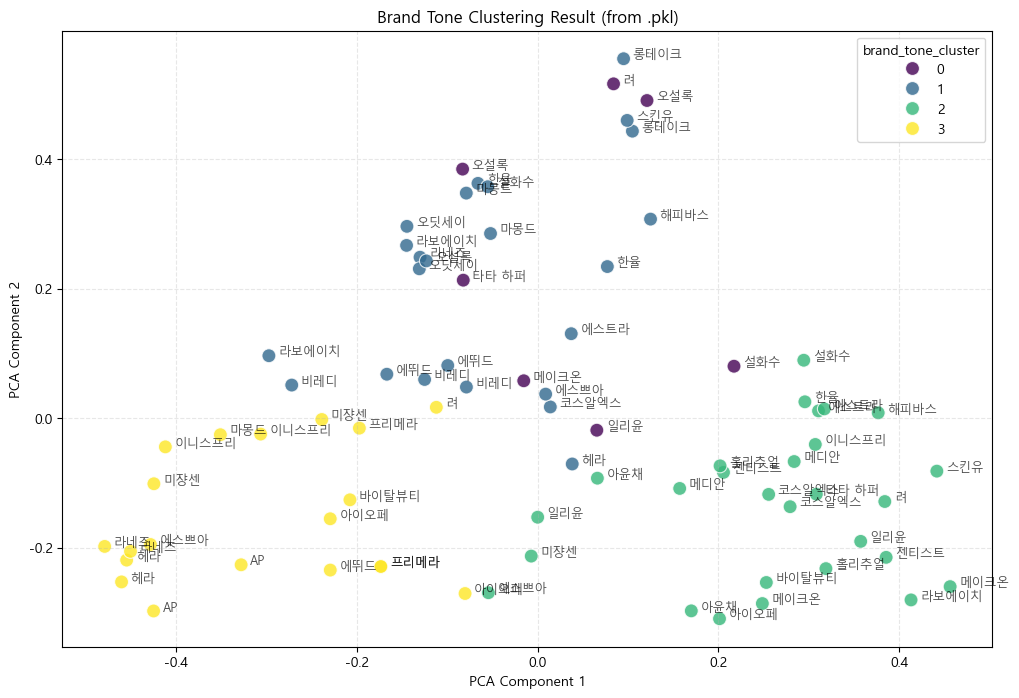


📂 최종 결과가 'brand_tone_segmented.csv'로 저장되었습니다.


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 데이터 로드 (Pickle 파일)
# ==========================================
file_path = "brand_analysis_result.pkl"  # 가지고 계신 pkl 파일명
print(f">>> '{file_path}' 파일을 로드합니다...")

# 🚀 핵심: pkl은 데이터 형태(리스트/배열)를 그대로 기억하므로 바로 읽으면 끝입니다.
df = pd.read_pickle(file_path)

# 데이터 확인 (벡터 컬럼이 정상적으로 있는지)
if 'embedding_vector' not in df.columns:
    print("❌ 오류: 'embedding_vector' 컬럼이 없습니다. pkl 파일을 확인해주세요.")
    exit()

# 벡터를 2차원 매트릭스로 변환 (행: 브랜드, 열: 768차원)
# pkl에서는 이미 리스트나 배열 형태이므로 바로 stack 하면 됩니다.
X = np.stack(df['embedding_vector'].values)

# ==========================================
# 2. 벡터 정규화
# ==========================================
X_normalized = normalize(X)

# ==========================================
# 3. K-Means 클러스터링 (군집화)
# ==========================================
# 4개의 그룹(세그먼트)으로 나눕니다.
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

print(f">>> {num_clusters}개의 그룹으로 브랜드를 분류합니다...")
df['brand_tone_cluster'] = kmeans.fit_predict(X_normalized)

# ==========================================
# 4. 결과 분석 및 시각화
# ==========================================

# (1) 각 군집별 포함된 브랜드 출력
print("\n" + "="*50)
print("📊 [클러스터링 결과 : 브랜드 그룹핑]")
print("="*50)

for i in range(num_clusters):
    print(f"\n🏷️  [Cluster {i}]")
    
    group_data = df[df['brand_tone_cluster'] == i]
    brands = group_data['브랜드'].unique()
    
    if '핵심 키워드' in df.columns:
        keywords = group_data['핵심 키워드'].head(3).values
        print(f"   ▶ 주요 키워드 힌트: {keywords}")
    
    print(f"   ▶ 브랜드 ({len(brands)}개): {', '.join(brands)}")

# (2) 시각화 (PCA 2차원 축소)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 폰트 (맥은 AppleGothic)
plt.rcParams['axes.unicode_minus'] = False

sns.scatterplot(
    x='pca_x', y='pca_y', 
    hue='brand_tone_cluster', 
    palette='viridis', 
    data=df, 
    s=100, 
    alpha=0.8
)

# 브랜드 이름 표시
for i in range(df.shape[0]):
    plt.text(
        df.pca_x[i]+0.01, 
        df.pca_y[i], 
        df.브랜드[i], 
        fontsize=9, 
        alpha=0.7
    )

plt.title('Brand Tone Clustering Result (from .pkl)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ==========================================
# 5. 결과 저장 (CRM 업로드용)
# ==========================================
output_file = "brand_tone_segmented.csv"
# 저장할 컬럼 선택
save_cols = ['브랜드', '구분', '내용 요약', 'brand_tone_cluster']
df[save_cols].to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"\n📂 최종 결과가 '{output_file}'로 저장되었습니다.")

In [2]:
import pandas as pd
import io

# ==========================================
# 1. 데이터 준비 (보내주신 CSV 데이터)
# ==========================================
csv_data = """브랜드,구분,내용 요약,brand_tone_cluster
에스트라,Part 1,태평양제약에서 시작된 헤리티지에 기반해 오래도록 건강한...,1
에스트라,Part 2,에스트라가 의사를 만나는 이유     일시적 윤기와 잠...,2
에스트라,Part 3,병원 밖으로 나온 더마 with 올리브영     에스트...,2
AP,Part 1,$APEX OF SKINCARE TO UNVEIL BE...,3
AP,Part 2,APEX OF SKINCARE     새로운 차원의 피...,3
아윤채,Part 1,Detailed & High Performing Sal...,2
아윤채,Part 2,디자이너 살롱 워크를 위한 PRO와 데일리 헤어 라이프...,2
비레디,Part 1,"Ordinary, but extraordinary   ...",1
비레디,Part 2,더 세련된 방식으로 나를 표현하도록 도와주는     각...,1
비레디,Part 3,중요한 순간에 준비된 나를 만들어주는     나의 스타...,1
코스알엑스,Part 1,"오직 성분으로, 오직 코스알엑스     ""Cosmeti...",1
코스알엑스,Part 2,미스터 알엑스는 오랜시간 동안 일상 속 뷰티 라이프 스...,2
코스알엑스,Part 3,brand concept Soft Skin Care  ...,2
에스쁘아,Part 1,자신만의 룩을 찾을 수 있도록 영감을 주는 Makeup...,1
에스쁘아,Part 2,Detailed by Professionals     ...,2
에스쁘아,Part 3,BEAUTY CREATED     BY DETAILS....,3
에뛰드,Part 1,Make Your Makeup Playlist! ETU...,3
에뛰드,Part 2,color 라이프 스타일의 다채로움     Pink 유...,1
에뛰드,Part 3,"Loved Products     자타공인, 역대 가장...",1
젠티스트,Part 1,구강 고민에 독창적인 솔루션을 제공하는 덴탈케어 브랜드...,2
젠티스트,Part 2,아모레퍼시픽의 전문적이고 체계적인 41년 구강 연구 노...,2
한율,Part 1,나만의 건강한 균형     Everyday glass ...,1
한율,Part 2,"한국의 이로움으로 전하는 균형 잡힌 아름다움, 한율  ...",1
한율,Part 3,"피부 스스로 강해질 수 있는 힘,     마이크로바이옴...",2
해피바스,Part 1,일상에 행복을 더하는 향과 건강한 원료를 담은     ...,1
해피바스,Part 2,"온가족이 함께 쓰는 바디클렌저, 안전한 원료와 믿을 수...",2
헤라,Part 1,Contemporary Seoul Beauty     ...,1
헤라,Part 2,SENSUAL POWDER MATTE LIQUID   ...,3
헤라,Part 3,CONTEMPORARY     SEOUL BEAUTY ...,3
홀리추얼,Part 1,Holistic Rituals for Skin Well...,2
홀리추얼,Part 2,우리는 거울 앞 무의미하게 반복되는 당신의 스킨케어 루...,2
일리윤,Part 1,Amorepacific     민감한 피부 고민에 대한...,2
일리윤,Part 2,"INTERVIEW 01     모윤희     (17, ...",2
일리윤,Part 3,주요성분     3가지 핵심성분     피토 세라마이드...,0
이니스프리,Part 1,"Effective, Nature-Powered Skin...",2
이니스프리,Part 2,the Origin of INNISFREE     천혜...,3
이니스프리,Part 3,with INNISFREE     Better for ...,3
아이오페,Part 1,클리니컬 레벨 테크(Clinical Level Tech...,3
아이오페,Part 2,IOPE LAB     아이오페 랩은 브랜드의 오리진으...,3
아이오페,Part 3,ESSENCE & BENEFIT     피부미래연구소 ...,2
라보에이치,Part 1,두피 스킨케어 전문가_라보에이치     아모레퍼시픽 피...,2
라보에이치,Part 2,LABOratory Of Honesty     진심을 ...,1
라보에이치,Part 3,스칼프베리어218™     라보에이치가 선택한 단 하나...,1
라네즈,Part 1,아름다움을 향한 끝없는 호기심     OPEN TO W...,1
라네즈,Part 2,THE CORE PRODUCT PILLARS     H...,3
라네즈,Part 3,SLEEPING BEAUTY TECHNOLOGY    ...,3
롱테이크,Part 1,깊은 숲에서 영감을 받은 감성향 지속가능 브랜드    ...,1
롱테이크,Part 2,사람의 발길이 닿지 않은 깊은 숲에서 영감을 받은 감각...,1
메이크온,Part 1,"피부를 잘 아는 뷰티 디바이스, 메이크온     메이크...",2
메이크온,Part 2,"메이크온은 빛(Light), 열(Heat), 이온(Io...",0
메이크온,Part 3,"쏟아져 나오는 뷰티 디바이스 제품들 사이에서, 메이크온...",2
마몽드,Part 1,Hyper Flora™로 피어나는 나다운 아름다움   ...,1
마몽드,Part 2,Powered by Hyper Flora     하이퍼...,3
마몽드,Part 3,자신만의 독특한 방식으로     삶을 꽃 피울 수 있도...,1
메디안,Part 1,내 치아를 위한 맞춤 처방     메디안은 “건강한 치...,2
메디안,Part 2,많은 고객에게 사랑을 받은 치석 전문 ‘치석케어 93%...,2
미쟝센,Part 1,SHINE YOUR SCENE     글로벌 헤어패션 ...,2
미쟝센,Part 2,"CHANGE YOUR HAIR, CHANGE YOUR ...",3
미쟝센,Part 3,"미쟝센을 만나는 순간,     모든 곳이 무대     ...",3
오딧세이,Part 1,매력적인 남성미와 미향(美香)을 향한 여정     오딧...,1
오딧세이,Part 2,25년이 넘는 남성 헤리티지의 오딧세이는 앞으로도 세련...,1
오설록,Part 1,Tea from Jeju Island     “어느 나...,1
오설록,Part 2,오설록의 제주 차밭     약 100만 평에 달하는 3...,0
오설록,Part 3,자연을 숨쉬게 하는 차밭     자연을 지키는 유기농 ...,0
프리메라,Part 1,All about skin barrier by SEED...,3
프리메라,Part 2,Powerful Result Mixology Recip...,3
프리메라,Part 3,Powerful Result Mixology Recip...,3
려,Part 1,뿌리로부터 자라는 본연의 아름다움     뿌리깊은 나무...,0
려,Part 2,2008년에 런칭한 ‘려’는 1973년부터 시작된 아모...,3
려,Part 3,최근 려는 원인과 증상이 다른 남녀의 탈모를 맞춤 케어...,2
스킨유,Part 1,내 몸의 감각을 일깨우는 섬세한 바디케어 브랜드 스킨유...,2
스킨유,Part 2,머스크향이 나는 자연의 열매인 암브레트 씨드를 향에 담...,1
설화수,Part 1,시간의 흐름에 지지 않는 아름다움     Journey...,1
설화수,Part 2,"집념의 60년 연구,     피부 장수를 위한 인삼  ...",0
설화수,Part 3,설화수가 만드는     윤빛 도는 힘 있는 피부    ...,2
타타 하퍼,Part 1,High-Performance Natural Skinc...,2
타타 하퍼,Part 2,타타 하퍼 농장에서 발견하는 자연의 이치와 과학을 토대...,0
바이탈뷰티,Part 1,VITALBEAUTIE     과학적 설계로 완성한 건...,3
바이탈뷰티,Part 2,"바이탈뷰티 랩은 영양 대사, 면역, 의약학, 이너뷰티 ...",2
"""

# CSV 로드
df = pd.read_csv(io.StringIO(csv_data))
print(f">>> 데이터 로드 완료! (총 {len(df)}개 행)")

# ==========================================
# 2. 클러스터 이름 매핑 (Naming)
# ==========================================
# 분석 결과를 바탕으로 정의한 이름
tone_mapping = {
    0: "헤리티지 & 힐링",
    1: "트렌디 & 라이프스타일",
    2: "더마 & 프로페셔널",
    3: "고기능 & 사이언스"
}

# 숫자를 이름으로 변경
print(">>> 숫자(0~3)를 CRM용 이름으로 변경 중...")
df['brand_position'] = df['brand_tone_cluster'].map(tone_mapping)

# ==========================================
# 3. 결과 확인 및 저장
# ==========================================
print("\n[변경 결과 미리보기]")
# 변경된 내용 일부 출력 (이름이 잘 바뀌었는지 확인)
print(df[['브랜드', 'brand_tone_cluster', 'brand_position']].head(10))

# 최종 파일 저장
output_file = "final_brand_segments.csv"
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print("\n" + "="*50)
print(f"✅ 최종 완료! '{output_file}' 파일이 생성되었습니다.")
print("👉 이제 이 파일을 CRM 시스템이나 마케팅 보고서에 바로 사용하시면 됩니다.")
print("="*50)

>>> 데이터 로드 완료! (총 79개 행)
>>> 숫자(0~3)를 CRM용 이름으로 변경 중...

[변경 결과 미리보기]
    브랜드  brand_tone_cluster brand_position
0  에스트라                   1   트렌디 & 라이프스타일
1  에스트라                   2     더마 & 프로페셔널
2  에스트라                   2     더마 & 프로페셔널
3    AP                   3     고기능 & 사이언스
4    AP                   3     고기능 & 사이언스
5   아윤채                   2     더마 & 프로페셔널
6   아윤채                   2     더마 & 프로페셔널
7   비레디                   1   트렌디 & 라이프스타일
8   비레디                   1   트렌디 & 라이프스타일
9   비레디                   1   트렌디 & 라이프스타일

✅ 최종 완료! 'final_brand_segments.csv' 파일이 생성되었습니다.
👉 이제 이 파일을 CRM 시스템이나 마케팅 보고서에 바로 사용하시면 됩니다.
